In [2]:
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn

from neuralhydrology.utils.config import Config

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run

import os
##### Change this! #####
test_data_dir = Path("./testData")
# test_data_dir = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/testData")

# Verify Model to T-Shirt (?) CFE
The goal of this section is to compare the existing dCFE code (as of 20241215) to CFE hourly outputs: https://github.com/NWC-CUAHSI-Summer-Institute/cfe_py/blob/main/cat58_test_compare.csv
The forcing for the same time period is: https://github.com/NWC-CUAHSI-Summer-Institute/cfe_py/blob/main/cat58_01Dec2015.csv
The basin settings (since basin id unknown) is here: https://github.com/NWC-CUAHSI-Summer-Institute/cfe_py/blob/main/bmi_cfe.py

Note that the forcing file as TMP_2maboveground which I assume is temperature in (K), so it needs to be converted to C before being used. And the initialized_basin_constants is adaped based on the bmi_cfe.py file. 

## Running CFE

In [3]:
forcingFile = pd.read_csv(test_data_dir/'cat58_01Dec2015.csv')
forcingsTest = torch.zeros(2, forcingFile.shape[0], 3) #[ "batch_size", forcings, time_step]
# grab shortwave radiation & temperature (K)
forcingsTest[0, :, 0] = torch.tensor(forcingFile.loc[:,'precip_rate'])
forcingsTest[0, :, 1] = torch.tensor(forcingFile.loc[:,'TMP_2maboveground'])
forcingsTest[0, :, 2] = torch.tensor(forcingFile.loc[:,'DSWRF_surface'])

In [4]:
from neuralhydrology.modelzoo.test_dcfeHourly import testCFE
# Create an instance of the testCFE class
test_cfe_instance = testCFE()

# Call the testRun method using the instance
runoffOut = test_cfe_instance.testRun(x_conceptual=forcingsTest)

# grab observations from acutal CFE
compareFile = pd.read_csv(test_data_dir/'cat58_test_compare.csv')

## Comparison

This only looks at one section of the whole time series, the same section that the original comparison did (not sure why they picked this specific section).

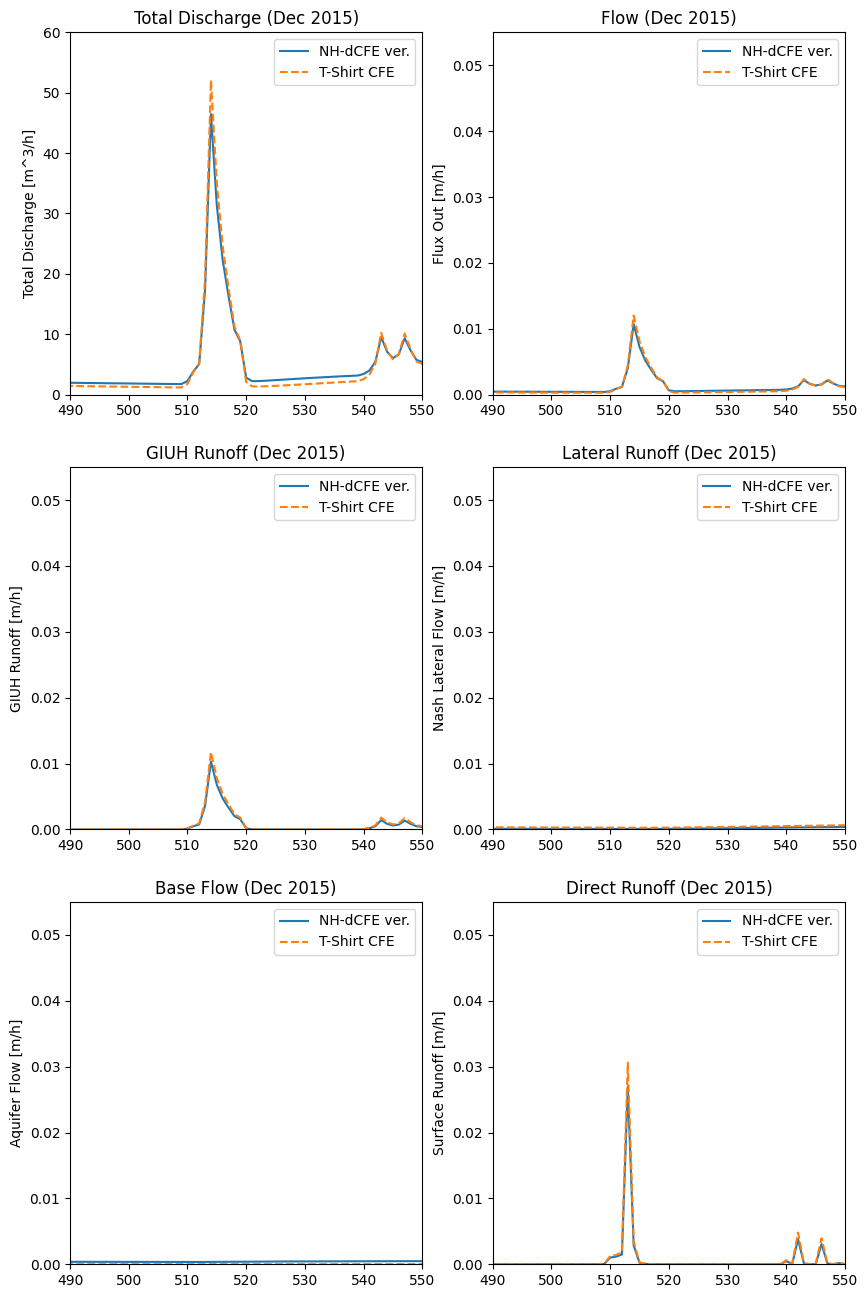

In [5]:
fig, ax = plt.subplots(3, 2, figsize=(10,16))

ax[0,0].plot(compareFile['Time Step'], runoffOut[:,0]*15.617167355002097 * 1000000.0 / 3600 , label="NH-dCFE ver.")
ax[0,0].plot(compareFile['Time Step'], compareFile['Total Discharge'], label="T-Shirt CFE", linestyle= 'dashed')
# Set labels and title
ax[0,0].set_ylabel("Total Discharge [m^3/h]")
ax[0,0].set_title(f"Total Discharge (Dec 2015)")
# Set axis limits
ax[0,0].set_xlim([490, 550]) 
ax[0,0].set_ylim([0, 60])  
ax[0,0].legend()

ax[0,1].plot(compareFile['Time Step'], runoffOut[:,0], label="NH-dCFE ver.")
ax[0,1].plot(compareFile['Time Step'], compareFile['Flow'], label="T-Shirt CFE", linestyle= 'dashed')
# Set labels and title
ax[0,1].set_ylabel("Flux Out [m/h]")
ax[0,1].set_title(f"Flow (Dec 2015)")
# Set axis limits
ax[0,1].set_xlim([490, 550])  
ax[0,1].set_ylim([0, 0.055])  
ax[0,1].legend()

ax[1,0].plot(compareFile['Time Step'], runoffOut[:,1], label="NH-dCFE ver.")
ax[1,0].plot(compareFile['Time Step'], compareFile['GIUH Runoff'], label="T-Shirt CFE", linestyle = 'dashed')
# Set labels and title
ax[1,0].set_ylabel("GIUH Runoff [m/h]")
ax[1,0].set_title(f"GIUH Runoff (Dec 2015)")
# Set axis limits
ax[1,0].set_xlim([490, 550]) 
ax[1,0].set_ylim([0, 0.055])   
ax[1,0].legend()

ax[1,1].plot(compareFile['Time Step'], runoffOut[:,2], label="NH-dCFE ver.")
ax[1,1].plot(compareFile['Time Step'], compareFile['Lateral Flow'],label="T-Shirt CFE", linestyle = 'dashed')
# Set labels and title
ax[1,1].set_ylabel("Nash Lateral Flow [m/h]")
ax[1,1].set_title(f"Lateral Runoff (Dec 2015)")
# Set axis limits
ax[1,1].set_xlim([490, 550]) 
ax[1,1].set_ylim([0, 0.055])   
ax[1,1].legend()

ax[2,0].plot(compareFile['Time Step'], runoffOut[:,3], label="NH-dCFE ver.")
ax[2,0].plot(compareFile['Time Step'], compareFile['Base Flow'],label="T-Shirt CFE", linestyle = 'dashed')
# Set labels and title
ax[2,0].set_ylabel("Aquifer Flow [m/h]")
ax[2,0].set_title(f"Base Flow (Dec 2015)")
# Set axis limits
ax[2,0].set_xlim([490, 550]) 
ax[2,0].set_ylim([0, 0.055])  
ax[2,0].legend()

ax[2,1].plot(compareFile['Time Step'], runoffOut[:,4], label="NH-dCFE ver.")
ax[2,1].plot(compareFile['Time Step'], compareFile['Direct Runoff'],label="T-Shirt CFE", linestyle = 'dashed')
# Set labels and title
ax[2,1].set_ylabel("Surface Runoff [m/h]")
ax[2,1].set_title(f"Direct Runoff (Dec 2015)")
# Set axis limits
ax[2,1].set_xlim([490, 550]) 
ax[2,1].set_ylim([0, 0.055])  
ax[2,1].legend()

They are all very very close. So this passes.

# Trained dCFE Model (dynamic spinup + prediction)
To do this, there are several steps. First, we'll need to examine parameters from a trained LSTM by
1. Grab data needed for LSTM, normalize them
2. Grab weights from trained LSTM model, use them to predict params
3. Graph params over time 

Second, verify "manually" computed outputs via CFE match NH computed outputs, & compare to "calibrated params"

4. Grab evaluated results from trained NH-dCFE model
5. Use calibrated fixed parameters to predict for same time period, and
6. Use time-varying parameters from before to predict for the same time period, compare runoff to both previous realizations (4, 5).

Thirdly, examine internal states and other quantity of interest.

7. Graph internal states overtime, make sure to have correct units

## Parameters from LSTM

In [6]:
# Define the path to the testData folder & grab data
inputLSTMFile = pd.read_csv(test_data_dir/'02177000_lstm_input.csv')

# Normalize the lstm input data
input_lstm = torch.zeros(2, len(inputLSTMFile), len(inputLSTMFile.columns) - 1) # [batch_size = 2, time_steps, forcing]
# ^^^weird batch size to minimum amout of code edits needed. Info will only be stored in [0,:,:]
input_lstm[0, :, 0] = torch.Tensor((inputLSTMFile['PRCP(mm/day)_nldas'].values - np.mean(inputLSTMFile['PRCP(mm/day)_nldas'].values))/
                                   np.std(inputLSTMFile['PRCP(mm/day)_nldas'].values))
input_lstm[0, :, 1] = torch.Tensor((inputLSTMFile['PRCP(mm/day)_maurer'].values - np.mean(inputLSTMFile['PRCP(mm/day)_maurer'].values))/
                                   np.std(inputLSTMFile['PRCP(mm/day)_maurer'].values))
input_lstm[0, :, 2] = torch.Tensor((inputLSTMFile['prcp(mm/day)_daymet'].values - np.mean(inputLSTMFile['prcp(mm/day)_daymet'].values))/
                                   np.std(inputLSTMFile['prcp(mm/day)_daymet'].values))
input_lstm[0, :, 3] = torch.Tensor((inputLSTMFile['srad(W/m2)_daymet'].values - np.mean(inputLSTMFile['srad(W/m2)_daymet'].values))/
                                   np.std(inputLSTMFile['srad(W/m2)_daymet'].values))
input_lstm[0, :, 4] = torch.Tensor((inputLSTMFile['tmax(C)_daymet'].values - np.mean(inputLSTMFile['tmax(C)_daymet'].values))/
                                   np.std(inputLSTMFile['tmax(C)_daymet'].values))
input_lstm[0, :, 5] = torch.Tensor((inputLSTMFile['tmin(C)_daymet'].values - np.mean(inputLSTMFile['tmin(C)_daymet'].values))/
                                   np.std(inputLSTMFile['tmin(C)_daymet'].values))
input_lstm[0, :, 6] = torch.Tensor((inputLSTMFile['vp(Pa)_daymet'].values - np.mean(inputLSTMFile['vp(Pa)_daymet'].values))/
                                   np.std(inputLSTMFile['vp(Pa)_daymet'].values))

Also define function to grab model weights and predict the params.

In [7]:
# Defining a function that grabs weights & makes prediction
def load_lstm_and_predict(input_data, weights_path, input_size, hidden_size, num_layers, output_size):
    """
    Load LSTM weights and make predictions using a function-based approach.
    
    Args:
        input_data (torch.Tensor): Input tensor of shape (batch_size, seq_length, input_size).
        weights_path (str): Path to the .pt file containing model weights.
        input_size (int): Number of input features per time step.
        hidden_size (int): Number of features in the hidden state.
        num_layers (int): Number of recurrent layers.
        output_size (int): Number of output features.
    
    Returns:
        torch.Tensor: Predictions from the model.
    """
    # Define the LSTM and linear layers
    lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
    fc = nn.Linear(hidden_size, output_size)
    
    # Load weights
    state_dict = torch.load(weights_path)
    
    # Map LSTM weights
    lstm_state_dict = {k.replace("lstm.", ""): v for k, v in state_dict.items() if k.startswith("lstm.")}
    lstm.load_state_dict(lstm_state_dict)
    
    # Map fully connected (linear) layer weights
    if "linear.weight" in state_dict and "linear.bias" in state_dict:
        fc_state_dict = {
            "weight": state_dict["linear.weight"],
            "bias": state_dict["linear.bias"]
        }
        fc.load_state_dict(fc_state_dict)
    else:
        raise RuntimeError("Missing keys for linear layer in state_dict. Check the key names.")
    
    # Set evaluation mode
    lstm.eval()
    fc.eval()
    
    # Perform forward pass
    with torch.no_grad():
        lstm_out, _ = lstm(input_data)  # Get output from LSTM
        lstm_pred = fc(lstm_out)  # Pass through the fully connected layer
    
    # Apply sigmoid and scaling to each column
    predictions = torch.zeros_like(lstm_pred)
    predictions[:, :, 0] = torch.sigmoid(lstm_pred[:, :, 0]) * 0.000726 + 0.0 # satdk
    predictions[:, :, 1] = torch.sigmoid(lstm_pred[:, :, 1]) * (0.0018 - 0.0000018) + 0.0000018 # Cgw
    predictions[:, :, 2] = torch.sigmoid(lstm_pred[:, :, 2]) * 21.94 + 0.0 # bb
    predictions[:, :, 3] = torch.sigmoid(lstm_pred[:, :, 3]) * (1.0 - 0.20554) + 0.20554 # smcmax
    predictions[:, :, 4] = torch.sigmoid(lstm_pred[:, :, 4]) * 1.0 + 0.0 # slop
    predictions[:, :, 5] = torch.sigmoid(lstm_pred[:, :, 5]) * (0.25 - 0.01) + 0.01 # max_gw
    predictions[:, :, 6] = torch.sigmoid(lstm_pred[:, :, 6]) * (8.0 - 1.0) + 1.0 # expon
    predictions[:, :, 7] = torch.sigmoid(lstm_pred[:, :, 7]) * 1.0 + 0.0 # K_lf
    predictions[:, :, 8] = torch.sigmoid(lstm_pred[:, :, 8]) * 1.0 + 0.0 # K_nash
    
    return predictions

def calculate_nse(observed, simulated):
    """
    Calculate the Nash-Sutcliffe Efficiency (NSE) between observed and simulated data.

    Parameters:
    observed (list or numpy array): Observed data values.
    simulated (list or numpy array): Simulated data values.

    Returns:
    float: The NSE value.
    """
    # Convert inputs to numpy arrays
    observed = np.array(observed)
    simulated = np.array(simulated)

    # Ensure the observed and simulated arrays have the same length
    if len(observed) != len(simulated):
        raise ValueError("Observed and simulated data must have the same length.")

    # Calculate the numerator and denominator of the NSE formula
    numerator = np.sum((observed - simulated) ** 2)
    denominator = np.sum((observed - np.mean(observed)) ** 2)

    # Avoid division by zero
    if denominator == 0:
        raise ValueError("The denominator of the NSE calculation is zero.")

    # Compute NSE
    nse = 1 - (numerator / denominator)

    return nse

Grab config file (could change to run_dir's config.yml too in the future), and predict the params using forcing.

In [8]:
# Grab config file that trained this model
#config_path = Path('/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology/examples/07-DifferentialCFE-Model/basin_dCFEwPETDaily.yml')
config_path = Path('./basin_dCFEwPETDaily.yml')
# Load the configuration file
config = Config(config_path, dev_mode=True)

# Grab results from evaluated model
run_dir = Path("runs/TestdCFEDaily_run02177000_GoodDynamic5epoch_1102_210529")
with open(run_dir / "test" / "model_epoch005" / "test_results.p", "rb") as fp:
    dCFE_results = pickle.load(fp)

input_size = input_lstm.shape[2] # the num of forcings input into lstm, tmax, tmin, precip etc etc
hidden_size = config.hidden_size
num_layers = 1
output_size = 9 # satdk, cgw, and 7 other outputs
weights_path = run_dir/"model_epoch005.pt"

torch.set_printoptions(precision=16)

# Example input data (batch_size=1, seq_length=5, input_size=10)
input_data = input_lstm

# Make predictions
LSTM_params = load_lstm_and_predict(input_data, weights_path, input_size, hidden_size, num_layers, output_size)


FileNotFoundError: [Errno 2] No such file or directory: 'runs/TestdCFEDaily_run02177000_GoodDynamic5epoch_1102_210529/test/model_epoch005/test_results.p'

Graphing the parameters and make sure there are units on the y-axis. Supplemental info on the parameters are here: https://github.com/NWC-CUAHSI-Summer-Institute/ngen-aridity/blob/main/Supplemental_Information.md

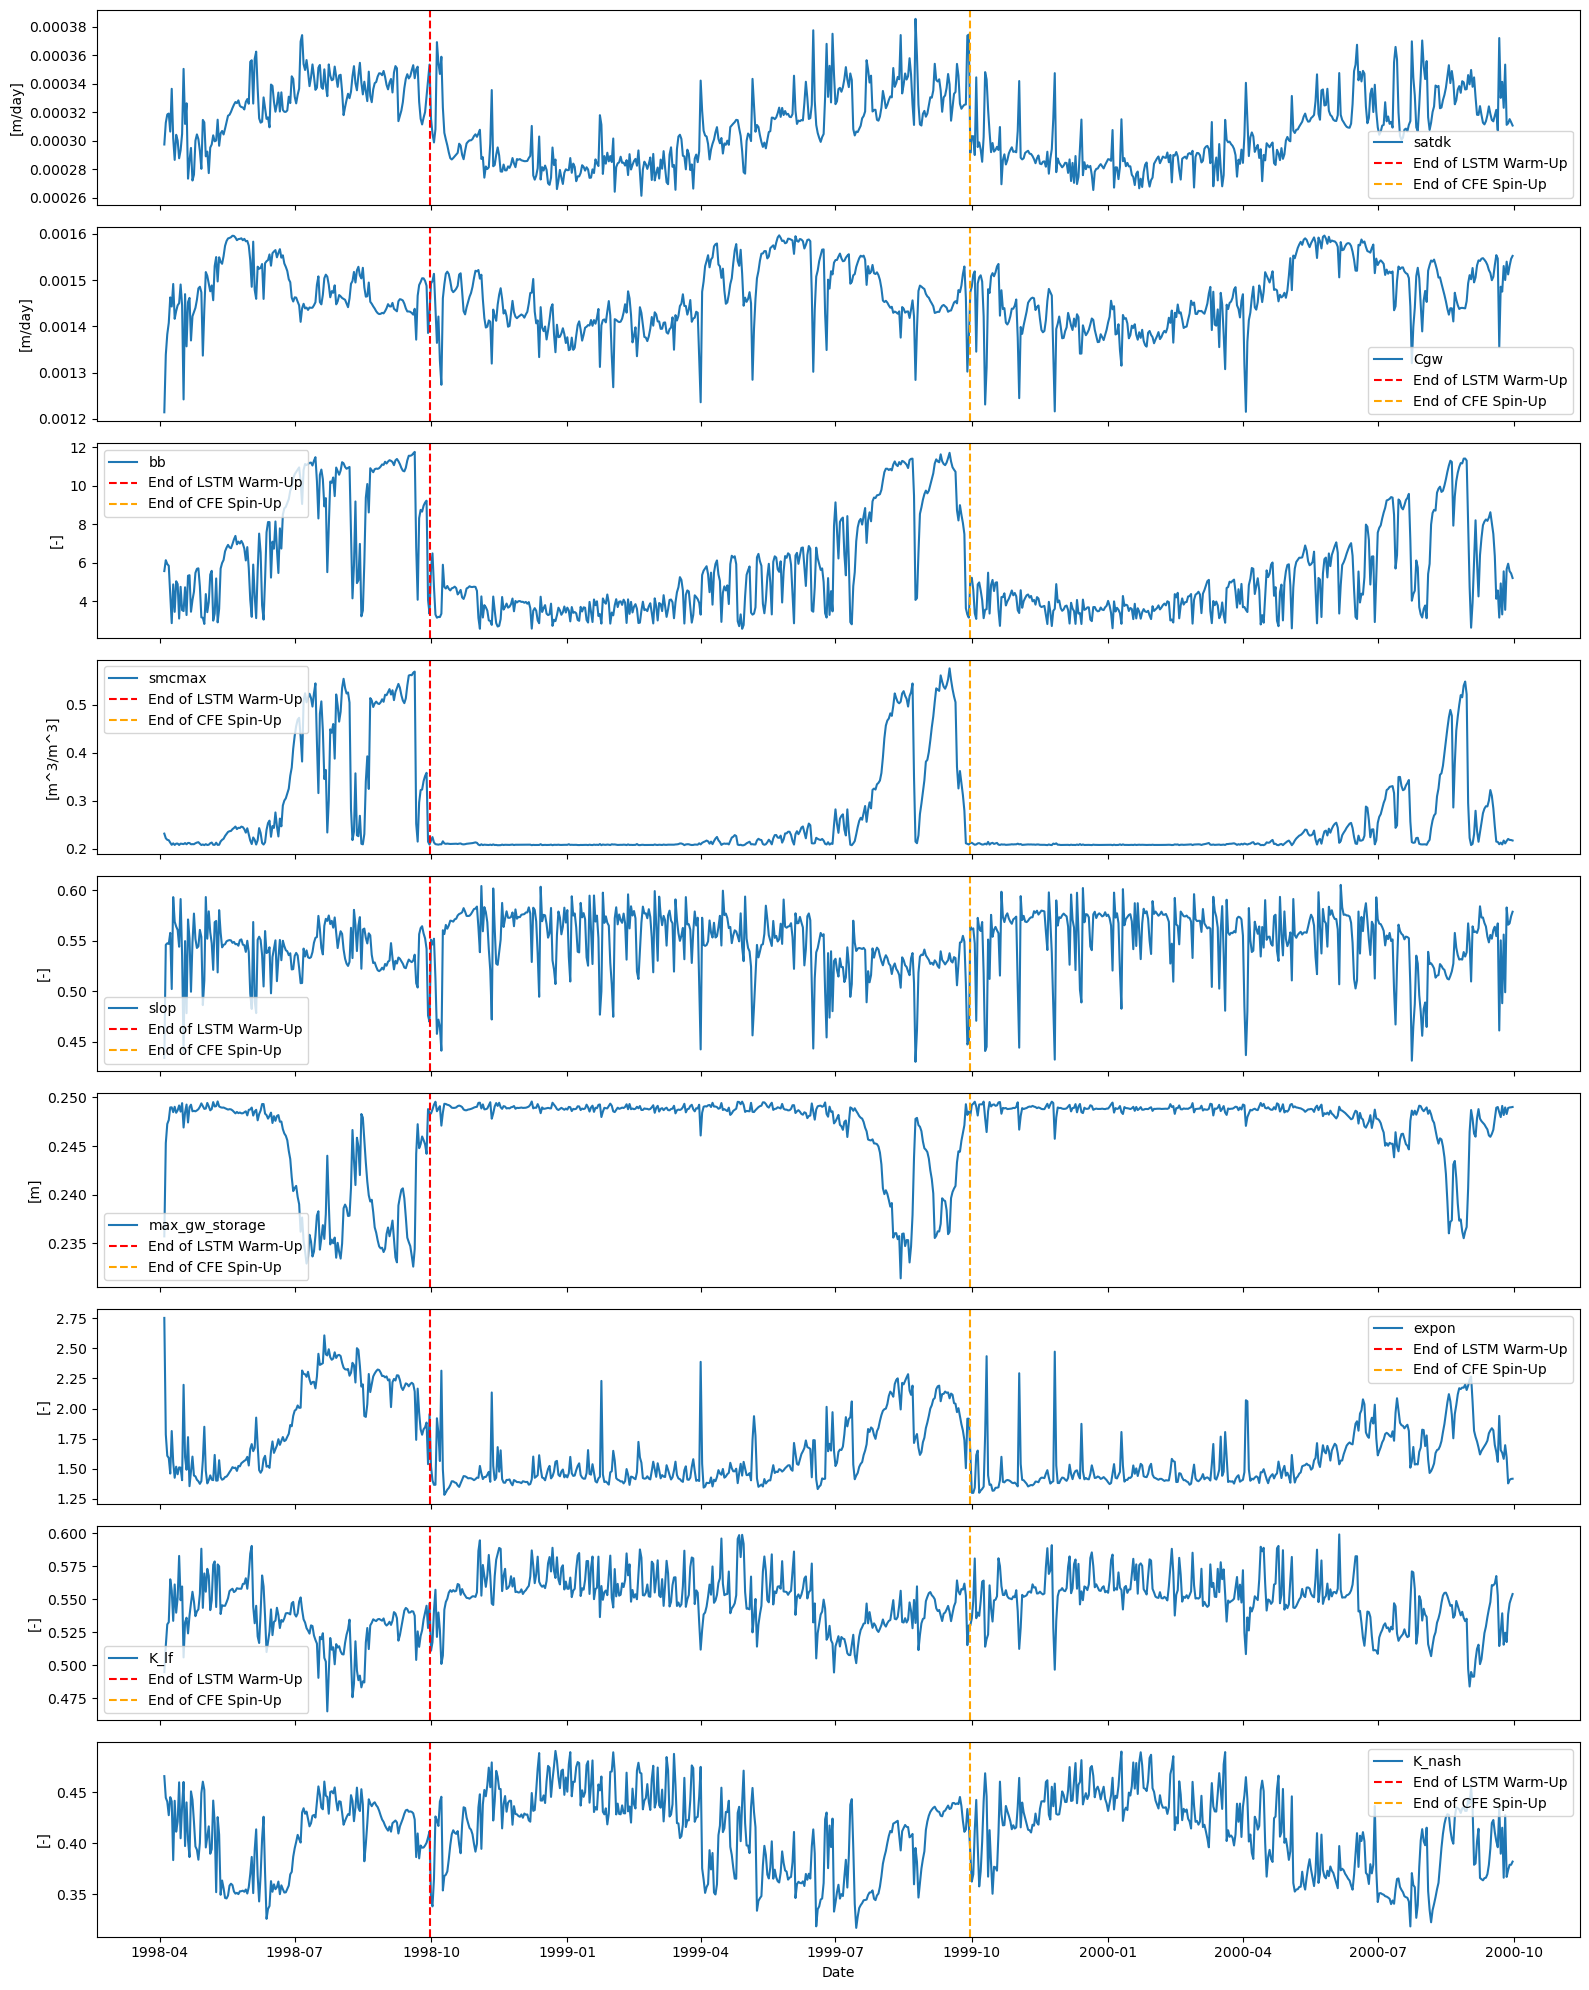

In [21]:
param_names = ['satdk', 'Cgw', 'bb', 'smcmax', 'slop', 'max_gw_storage', 'expon', 'K_lf', 'K_nash']
param_units = ['[m/day]', '[m/day]', '[-]', '[m^3/m^3]', '[-]', '[m]', '[-]', '[-]', '[-]'] # [-] means unitless

# Extract dates from input_lstm
dates_param = pd.date_range(start='1998-04-04', periods=input_lstm.shape[1], freq='D')

# Plot all columns of the predictions against the dates
fig, axes = plt.subplots(nrows=9, ncols=1, figsize=(16, 20), sharex=True)
for i in range(9):
    axes[i].plot(dates_param, LSTM_params[0, :, i].numpy(), label=param_names[i])
    axes[i].axvline(pd.Timestamp('1998-09-30'), color='red', linestyle='--', label='End of LSTM Warm-Up') 
    axes[i].axvline(pd.Timestamp('1999-09-30'), color='orange', linestyle='--', label='End of CFE Spin-Up') 
    axes[i].set_ylabel(param_units[i])
    axes[i].legend()

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


## NH-dCFE Runoff: Validation & Comparison

Grab forcings for CFE.

In [22]:
input_cfe = torch.zeros(2, input_lstm.shape[1], 4) #[ "batch_size", forcings, time_step]
input_cfe[0, :, 0] = torch.tensor(inputLSTMFile['PRCP(mm/day)_nldas'].values) # 1998 - 2000, 2 water years
input_cfe[0, :, 1] = torch.tensor(inputLSTMFile['tmin(C)_daymet'].values)
input_cfe[0, :, 2] = torch.tensor(inputLSTMFile['tmax(C)_daymet'].values)
input_cfe[0, :, 3] = torch.tensor(inputLSTMFile['srad(W/m2)_daymet'].values)

Compute CFE w/ dynamic params from the LSTM and also CFE w/ calibrated parameters from the HydroShare (https://www.hydroshare.org/resource/f7d6db8f8677402d808531924bbcf60c/) that is a result of a different study:

Araki, R., S. A. Bhuiyan, L. Cunha, T. Bindas, J. Rapp, J. Frame, J. M. Frame (2025). CUAHSI-SI23 Theme-1 Nextgen-aridity: CFE config & outputs, HydroShare, https://doi.org/10.4211/hs.f7d6db8f8677402d808531924bbcf60c

In [23]:
from neuralhydrology.modelzoo.dcfe import dCFE 
from neuralhydrology.utils.dCFE_utils import get_dcfe_params, expand_dcfe_params_along_batch_dim

temp_soil_params, temp_basinCharacteristics = get_dcfe_params(config, 'mps')
# store them as calibrated parameters for the calibrated-CFE comparison
# batchsize of 2 is placeholder, so we can do minimum amount of code edits. Info will be in first batch sample only
calibrated_soil_params = expand_dcfe_params_along_batch_dim(temp_soil_params, batch_size=2)
calibrated_basinCharacteristics = expand_dcfe_params_along_batch_dim(temp_basinCharacteristics, batch_size=2)

# calibrated parameters from HydroShare
calibrated_params = torch.zeros_like(LSTM_params)
calibrated_params[:, :, 0] = calibrated_soil_params['satdk'].unsqueeze(1).repeat(1, LSTM_params.shape[1])
calibrated_params[:, :, 1] = calibrated_basinCharacteristics['Cgw'].unsqueeze(1).repeat(1, LSTM_params.shape[1])
calibrated_params[:, :, 2] = calibrated_soil_params['bb'].unsqueeze(1).repeat(1, LSTM_params.shape[1])
calibrated_params[:, :, 3] = calibrated_soil_params['smcmax'].unsqueeze(1).repeat(1, LSTM_params.shape[1])
calibrated_params[:, :, 4] = calibrated_soil_params['slop'].unsqueeze(1).repeat(1, LSTM_params.shape[1])
calibrated_params[:, :, 5] = calibrated_basinCharacteristics['max_gw_storage'].unsqueeze(1).repeat(1, LSTM_params.shape[1])
calibrated_params[:, :, 6] = calibrated_basinCharacteristics['expon'].unsqueeze(1).repeat(1, LSTM_params.shape[1])
calibrated_params[:, :, 7] = calibrated_basinCharacteristics['K_lf'].unsqueeze(1).repeat(1, LSTM_params.shape[1])
calibrated_params[:, :, 8] = calibrated_basinCharacteristics['K_nash'].unsqueeze(1).repeat(1, LSTM_params.shape[1])

# establish an instance of the CFE model
CFE_instance = dCFE(config)
# get output of the CFE model with calibrated HydroShare parameters from a different study
CFE_calibrated_results = CFE_instance.testCFE_Daily(x_conceptual = input_cfe[:, 180:, :], 
                                                    parameters = calibrated_params[:, 180:, :])

# establish an instance of the CFE model
CFE_instance = dCFE(config)
# get output of the CFE model with dynamic LSTM parameters from the NH-dCFE model
# do not include the LSTM spin-up parameters
CFE_dynamic_results = CFE_instance.testCFE_Daily(x_conceptual = input_cfe[:, 180:, :], 
                                                 parameters = LSTM_params[:, 180:, :])


Grab NH-dCFE results.

In [24]:
dCFE_results['02177000']['1D']['NSE'] # for some reason NH calculated NSE wrong for this setting

# Extract a date slice of observations and simulations
dCFE_Result_xr = dCFE_results['02177000']['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar date and the 1D array of time_step values
date_scalar = dCFE_Result_xr.coords['date'][0].values  # Extract as a NumPy scalar
time_step_values = dCFE_Result_xr.coords['time_step'].values  # Extract as NumPy array

# Broadcast the scalar date across time_step and add the timedelta
datetime_values = date_scalar + pd.to_timedelta(time_step_values, unit='D')

# Add the datetime as a new coordinate to Result_xr
dCFE_Result_xr = dCFE_Result_xr.assign_coords(datetime=("time_step", datetime_values))

Plotting.

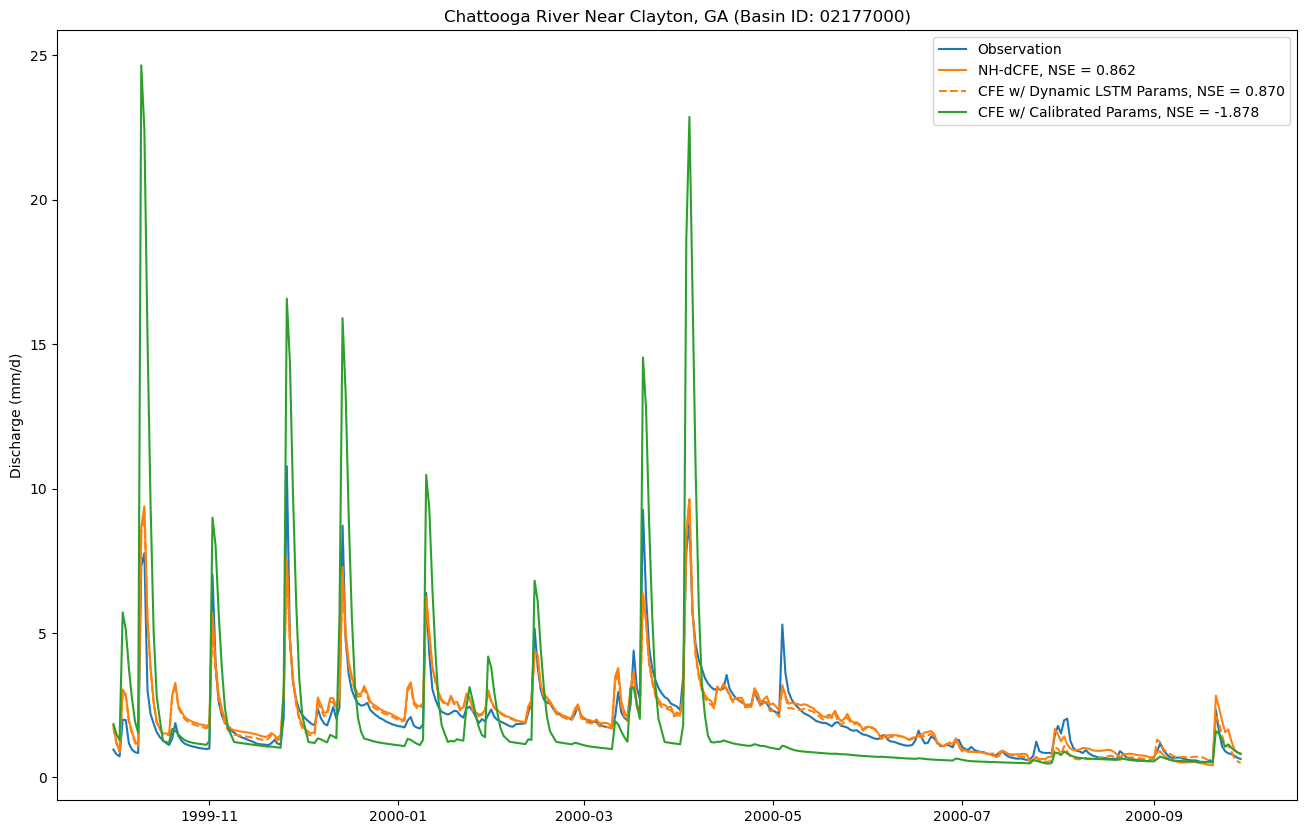

In [25]:
# grab colors for easy graphing
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Extract observations and simulations from NH-dCFE
dCFE_qobs = dCFE_Result_xr['QObs(mm/d)_obs']
dCFE_qsim = dCFE_Result_xr['QObs(mm/d)_sim']

# Calculate NSE manually since NH calculated it wrong
dCFE_result_NSE = calculate_nse(dCFE_qobs[0,:], dCFE_qsim[0,:])
CFE_dynamic_NSE = calculate_nse(dCFE_qobs[0,:], CFE_dynamic_results[-366:-1,0]*1000)
CFE_calibrated_NSE = calculate_nse(dCFE_qobs[0,:], CFE_calibrated_results[-366:-1,0]*1000)
# Plot observations and simulations
fig, ax = plt.subplots(figsize=(16, 10))
ax.plot(dCFE_Result_xr['datetime'], dCFE_qobs[0,:], label="Observation", color = colors[0])
ax.plot(dCFE_Result_xr['datetime'], dCFE_qsim[0,:], label=f"NH-dCFE, NSE = {dCFE_result_NSE:.3f}",
        color = colors[1])
ax.plot(dCFE_Result_xr['datetime'], CFE_dynamic_results[-366:-1,0]*1000, 
        label=f"CFE w/ Dynamic LSTM Params, NSE = {CFE_dynamic_NSE:.3f}",
        linestyle = 'dashed', color = colors[1])
ax.plot(dCFE_Result_xr['datetime'], CFE_calibrated_results[-366:-1,0]*1000, 
        label=f"CFE w/ Calibrated Params, NSE = {CFE_calibrated_NSE:.3f}",
        color = colors[2])
ax.set_ylabel("Discharge (mm/d)")
ax.set_title("Chattooga River Near Clayton, GA (Basin ID: 02177000)")
_ = ax.legend()

Note that in the above plot, NH-dCFE and "CFE w/ Dynamic LSTM Params" should match up well since those LSTM parameters are from the trained model --- they should give the same outputs. We can see that they don't match up perfectly in some areas, this might be due to normalized inputs into the LSTM where NH had a larger sample (more than 2.5yrs) and hence the normalized inputs are slightly different than this manual computation. But they are pretty close. The computation below shows NSE = 0.987 which is very close to 1 between the dCFE and "CFE w/ Dynamic LSTM Params", meaning they are almost the same. 

Aslo, "CFE w/ Calibrated Params" looks bad in a suspicious way. I did check the HydroShare, where the file "all_cat_performance_values.csv" contain the results of the calibration where this basin (labeled as 2177000 I believe) has average NSE = 0.505. But it is unclear if this exact time-period was in that average NSE in that study, and also it has been looking pretty bad for this basin in the past too using a different way of running CFE so probably nothing is wrong with the input. 

All simulations were spin-up for 1 year. 

In [26]:
print(calculate_nse(dCFE_qsim[0,:], CFE_dynamic_results[-366:-1,0]*1000), calculate_nse(dCFE_qsim[0,:], CFE_calibrated_results[-366:-1,0]*1000))
# first number is NSE between NH-dCFE and CFE with dynamic LSTM params
# 2nd number is NSE between NH-dCFE and CFE with calibrated params

0.9868991179391742 -2.1054160594940186


Now we can say that we have succesfully validated CFE with dynamic LSTM parameters with NH-dCFE output, so the internal states of this model would be representative to that of NH-dCFE which is difficult to probe.

## Internal States Comparison

First, compute all variable of interest in units of (mm). This list of states of interest are adapted from what Andy said to look into. 

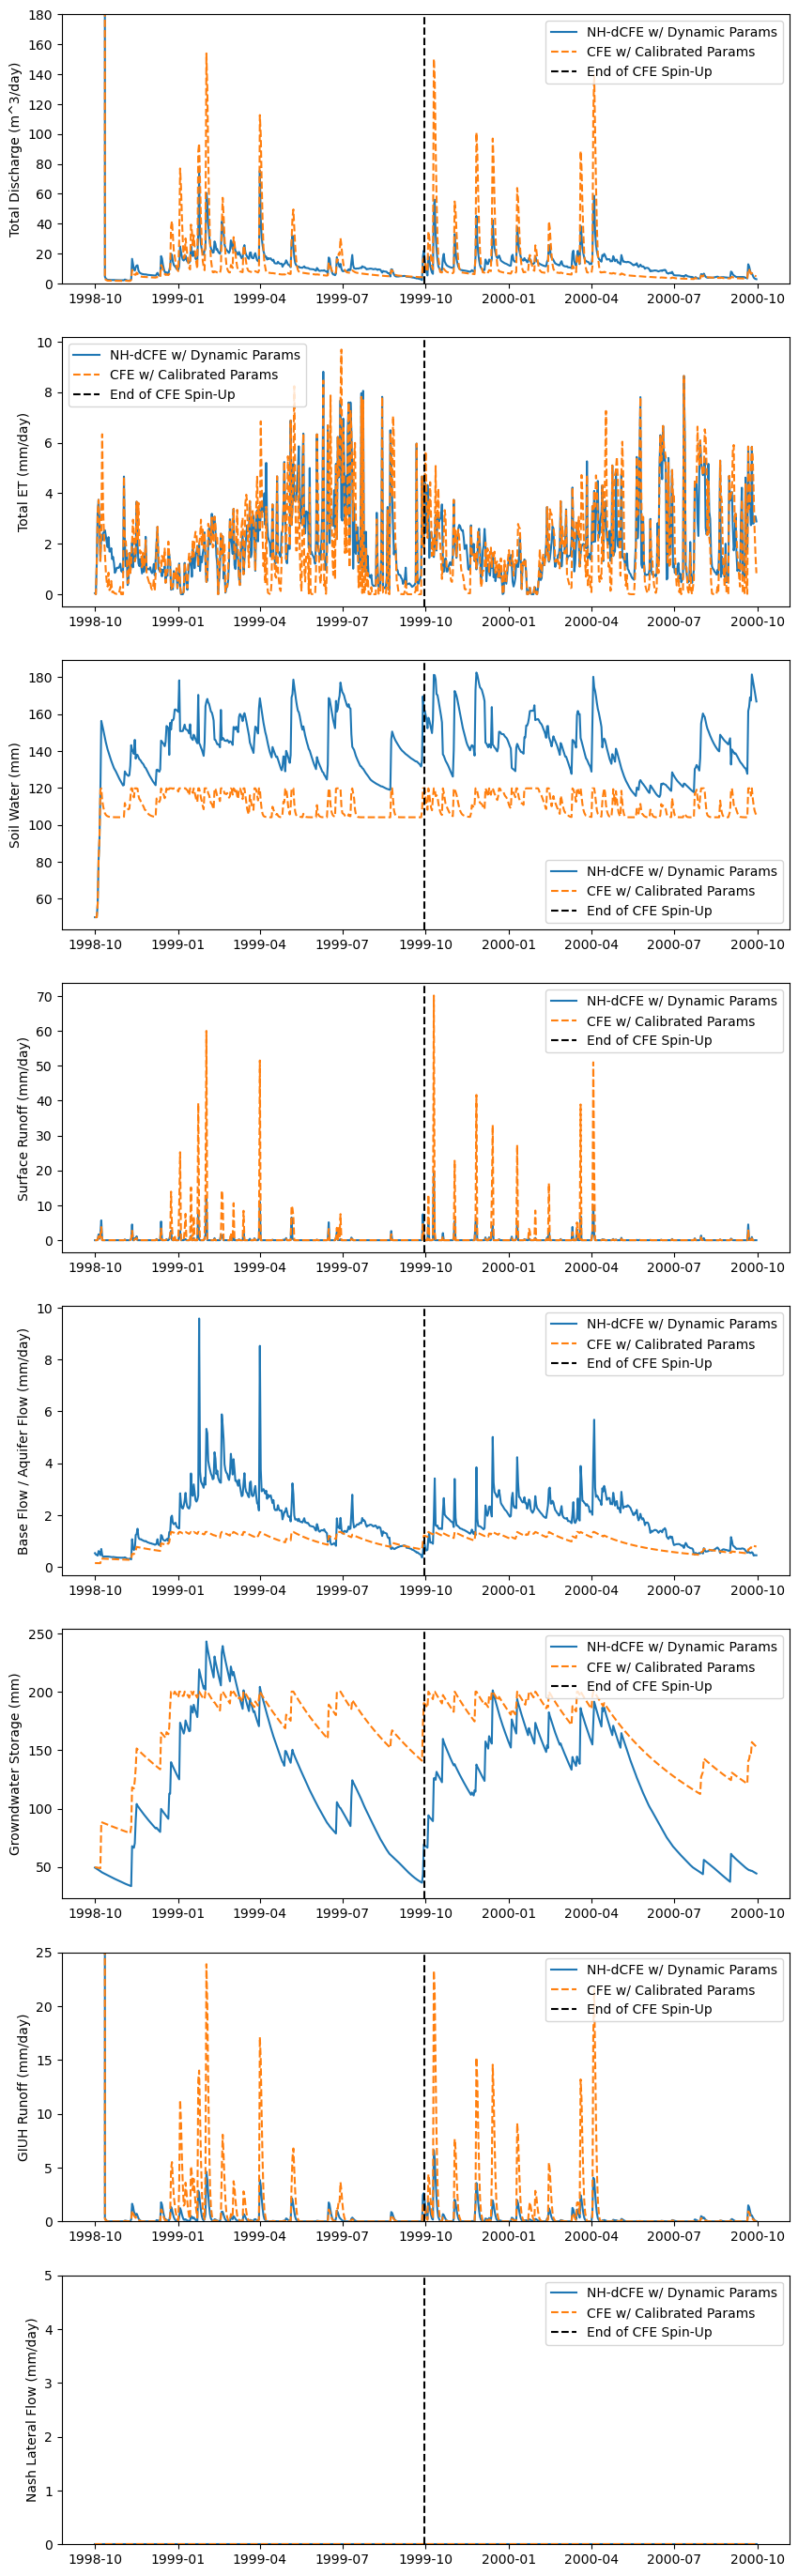

In [27]:
fig, ax = plt.subplots(8, 1, figsize=(10,35))

# plotting total discharge (m^3/day) = runoff (m/day) * area (km^2) * 1000000.0 / (3600*24)
ax[0].plot(dates_param[180:], CFE_dynamic_results[:,0]*526.77 * 1000000.0 / (3600*24), label = 'NH-dCFE w/ Dynamic Params')
ax[0].plot(dates_param[180:], CFE_calibrated_results[:,0]*526.77 * 1000000.0 / (3600*24), label = 'CFE w/ Calibrated Params', linestyle = 'dashed')
ax[0].set_ylabel("Total Discharge (m^3/day)")
# Set axis limits 
ax[0].set_ylim([0, 180])  
ax[0].legend()

# plotting total ET (mm/day) = actual_et_m_per_timestep * 1000
ax[1].plot(dates_param[180:], CFE_dynamic_results[:,5]*1000, label = 'NH-dCFE w/ Dynamic Params')
ax[1].plot(dates_param[180:], CFE_calibrated_results[:,5]*1000, label = 'CFE w/ Calibrated Params', linestyle = 'dashed')
ax[1].set_ylabel("Total ET (mm/day)")
ax[1].legend()

# plotting soil water storage (mm) = soil_storage_m * 1000
ax[2].plot(dates_param[180:], CFE_dynamic_results[:,6]*1000, label = 'NH-dCFE w/ Dynamic Params')
ax[2].plot(dates_param[180:], CFE_calibrated_results[:,6]*1000, label = 'CFE w/ Calibrated Params', linestyle = 'dashed')
ax[2].set_ylabel("Soil Water (mm)")
ax[2].legend()

# plotting surface flow (mm/day) = surface_runoff_depth_m * 1000
ax[3].plot(dates_param[180:], CFE_dynamic_results[:,4]*1000, label = 'NH-dCFE w/ Dynamic Params')
ax[3].plot(dates_param[180:], CFE_calibrated_results[:,4]*1000, label = 'CFE w/ Calibrated Params', linestyle = 'dashed')
ax[3].set_ylabel("Surface Runoff (mm/day)")
ax[3].legend()

# plotting base flow / aquifer flow (mm/day) = flux_from_deep_gw_to_chan_m * 1000
ax[4].plot(dates_param[180:], CFE_dynamic_results[:,3]*1000, label = 'NH-dCFE w/ Dynamic Params')
ax[4].plot(dates_param[180:], CFE_calibrated_results[:,3]*1000, label = 'CFE w/ Calibrated Params', linestyle = 'dashed')
ax[4].set_ylabel("Base Flow / Aquifer Flow (mm/day)")
ax[4].legend()

# plotting groundwater storage (mm) = gw_storage_m* 1000
ax[5].plot(dates_param[180:], CFE_dynamic_results[:,7]*1000, label = 'NH-dCFE w/ Dynamic Params')
ax[5].plot(dates_param[180:], CFE_calibrated_results[:,7]*1000, label = 'CFE w/ Calibrated Params', linestyle = 'dashed')
ax[5].set_ylabel("Growndwater Storage (mm)")
ax[5].legend()

# plotting GIUH flow (mm/day) = flux_giuh_runoff_m * 1000
ax[6].plot(dates_param[180:], CFE_dynamic_results[:,1]*1000, label = 'NH-dCFE w/ Dynamic Params')
ax[6].plot(dates_param[180:], CFE_calibrated_results[:,1]*1000, label = 'CFE w/ Calibrated Params', linestyle = 'dashed')
ax[6].set_ylabel("GIUH Runoff (mm/day)")
ax[6].set_ylim([0, 25])  
ax[6].legend()

# plotting Nash Lateral Flow (mm/day) = flux_nash_lateral_runoff_m * 1000
ax[7].plot(dates_param[180:], CFE_dynamic_results[:,2]*1000, label = 'NH-dCFE w/ Dynamic Params')
ax[7].plot(dates_param[180:], CFE_calibrated_results[:,2]*1000, label = 'CFE w/ Calibrated Params', linestyle = 'dashed')
ax[7].set_ylabel("Nash Lateral Flow (mm/day)")
ax[7].set_ylim([0, 5])  
ax[7].legend()

for i in range(8):
    ax[i].axvline(pd.Timestamp('1999-09-30'), color="black", linestyle='--', label='End of CFE Spin-Up') 
    ax[i].legend()